# Thunderhead Gunner Might Be the Best Red Common

<span>
<img src="https://cards.scryfall.io/large/front/3/0/30077b49-b825-4dbb-a0c7-f3992f647df0.jpg?1738356438" width=200>
<img src="https://cards.scryfall.io/large/front/e/f/ef537868-b2cb-4bbd-a935-b7f73f19bd06.jpg?1738359123" width=200>
</span>

I won't lie: this article was originally titled "Lightning Strike is the Best Red Common." After all, it is ranked higher in [DEq](https://docs.google.com/spreadsheets/d/1n1pfrb5q_2ICYk-vfF3Uwo8t61DJU-5T_DFe0dwk8DY/edit?usp=sharing), my card quality metric, so it must be, right? But let's back up a bit.

Aetherdrift has overturned a lot of received notions about card quality from the past two or three years, and Lightning Strike has certainly been a casualty, matching up poorly against some of the green bodies dominating the format like Hazard of the Dunes. On the other hand, with the slower pace of play and the potential to accrue value over a long game, Thunderhead Gunner has been a surprise outperformer. Then there's this (data as of Feb 19):

 Name | ATA | GIH WR  | DEq | DEq Grade
---| --- | --- | --- | --- 
 Lightning Strike | 3.92 | 55.1% | +1.62% |  B- 
 Thunderhead Gunner | 7.74 | 56.4% | +0.99% | C+ 

I included some other stats relevant to the argument, but GIH WR, by far the most referenced objective measure of card performance, has Gunner 1.3% clear of Lightning Strike. On top of that, 55.1% is just... mediocre. It's hard to imagine why a card with a perfectly average GIH WR should be assigned a B-, but that's what DEq is spitting out. Instead of getting into the justification of the metric, which I've done [elsewhere](deq), I'm going to dive into some historical comparisons where we have access to the full public data to break down what's going on in detail.

Lightning Strike is an early pick, and Thunderhead Gunner, relatively speaking, at this point of the format, is a late pick. I use ATA for observed pick orders, and we see the gap is almost 4 picks. Generally, higher picked cards perform better (about 0.3% per unit ATA), so this is a notable inversion of expectations. This disparity in pick order has the potential to drive the misevaluation by GIH WR, for two independent reasons. 

First, ATA directly captures card quality. It does this by recording information about the cost paid by the 17lands user to draft the card. When we observe the win rate achieved by users with Lightning Strike in their pool, we also know the pick missing from their remaining pool, pick 3.92 from one pack, on average. The drafters observed to take Thunderhead Gunner, by comparison got to build their decks with an extra fourth pick at the expense of an eighth pick, on average, and earned some win rate from that. On the other hand, when we are choosing between Lightning Strike and Thunderhead Gunner, we don't have to pay anything extra, we just take the card we like and put it in our pile. So as a result we should give a mental bonus (or write one down) to early picks when evaluating their win rates.


Second, more subtly, when late picks outperform expectations, there are more opportunities for them to be passed to, and then taken by, more skilled drafters. The more skilled drafters take a card, the better it will perform, regardless of the actual quality of the card. Once again, when we have to choose between the two cards, we regrettably do not get an increase in skill by simply making the correlated choice. So we should adjust for this difference, if we can measure it.

On the other hand, we will see a third, mitigating factor, that makes the situation less clear than I expected. Lightning Strike being a highly picked card means that when it does come around later, that is correlated with red being open and your deck being overall higher quality. Gunner, on the other hand, is a late pick, and can be drafted even when red is not open. I have an adjustment that is supposed to account for the effect of later picks being impacted by the surrounding quality (There's a reason I've had Alacrian Jaguar at C- since day one, despite it catching green's overall glow in GIH WR), but the special status of Gunner as the top-performing card in red seems to have a special effect, where it potentially bears the burden of carrying decks when red is less open. We will see when we break down examples below.


We don't have access to full public data yet to break down this example by skill and pick, so we will turn to comparisons in previous formats. I just did a manual scan of 17Lands to find analagous situations. Let's dig in.


## LCI: Etali's Favor vs Abrade
<span>
<img src="https://cards.scryfall.io/large/front/f/e/fee393c7-1868-4d11-93c3-3d143e0c8dd9.jpg?1736468077" width=200>
<img src="https://cards.scryfall.io/large/front/6/d/6d4075a8-c15d-4078-bf4b-0f85c03fecec.jpg?1699044282" width=200>
</span>


 Name | ATA | GIH WR  | DEq | DEq Grade
---| --- | --- | --- | --- 
 Abrade | 3.21 | 57.1% | +2.68% |  B
 Etali's Favor | 7.95 | 58.2% | +1.31% | C+ 

This is almost the identical situation. If we expect Lightning Strike to be better than Gunner, we should expect to find solid evidence that Abrade outperformed Etali's Favor. First, let's check out the skill distribution. I estimate player skill using the anonymized player buckets provided by 17Lands in the public data, which give broad groups by number of games and win rate. The methodology can be found [here](bayes-cohorts). To get the full picture of the card performance, we will look at the entire format.

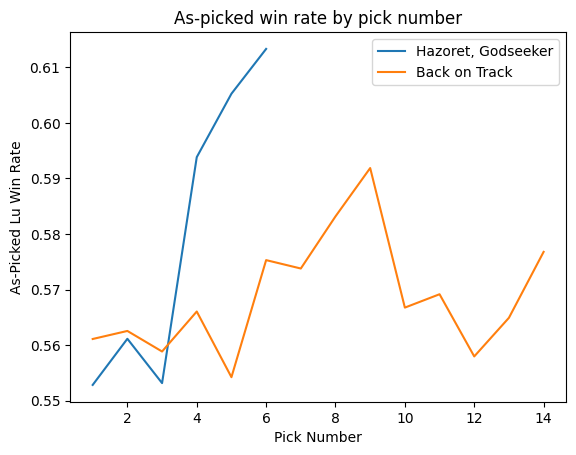

In [3]:
names = ["Hazoret, Godseeker", "Back on Track"]

df = summon("DFT", columns=["event_matches_sum","picked_match_wr"], group_by=["pick_num", "name"]).filter(pl.col("name").is_in(
    names
)).filter(pl.col("event_matches_sum")>50)


_, ax = plt.subplots()
for name in names:
    curve = df.filter(pl.col("name")==name)
    curve = curve.sort("pick_num") 
    ax.plot(
        curve["pick_num"],
        curve["picked_match_wr"],
        label=name     
    )
ax.legend()
ax.set_title("As-picked win rate by pick number")
ax.set_xlabel("Pick Number")
ax.set_ylabel("As-Picked Lu Win Rate")

plt.show()


In [4]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

from spells import summon
from deq import ext
from great_tables import GT



names = ["Hazoret, Godseeker", "Back on Track"]
set_code = "DFT"

wr_col = (pl.col('wr_weight')/pl.col('weight')).alias('adj_wr')

def wr_breakdown(set_code, names):
    return (
        summon(
            set_code, 
            columns=['event_match_wins_sum', 'event_matches_sum'], 
            group_by=['skill_cohort', 'pick_num', 'name'],
            filter_spec={'lhs': 'format_day', 'op': '>', 'rhs': 2},
            extensions=ext
        ).filter(pl.col('name').is_in(names))
        .filter(pl.col("event_matches_sum") > 50)
        .with_columns(pl.col("event_matches_sum").sum().over("skill_cohort", "pick_num").alias("weight"))

        .filter(pl.col("weight")>pl.col("event_matches_sum"))
        .with_columns((pl.col("event_match_wins_sum")/
                       pl.col("event_matches_sum")*pl.col("weight")).alias("wr_weight"))
    )

df = wr_breakdown(set_code, names)


In [5]:
df.group_by("name").sum().select("name",
    (pl.col("wr_weight")/pl.col("weight")).alias("adj_wr"))




name,adj_wr
str,f64
"""Hazoret, Godseeker""",0.556753
"""Back on Track""",0.559572


Etali's Favor, the later picked card, was indeed chosen more by more skilled players than Abrade, as expected. Let's look at the impact of this effect on win rate. We will use the "As Picked" win rate to look simply at the outcome of the draft choice. For the adjustment, we divide the number of observations by the observed ratio of picks by the skill cohort so that each card is picked equally often by each skill cohort in the weighting -- but still at the observed ratio by pick number within each cohort.

That knocks off exactly half of Favor's advantage. Next we'll break things down by pick. The first thing I did was apply an adjustment to enforce an equivalent distribution by pick number. 


For a simple example of the calculation, consider the following situation:

Card | Pick | Games | Wins
--- | --- | --- | ---
A | 1 | 5| 2 
A | 2 | 1| 1
B | 1| 1 | 0
B | 2| 5 | 4

Overall, card A has a 50% win rate and card B has a 67% win rate, but broken down by pick we see card A outperforms at each slot: 40% vs 0% at pick 1 and 100% vs 80% at pick 2. With a larger sample size we might have confidence that card A is in fact better despite the lower overall win rate.

The calculation we will do will normalize the pick distrubution using the sum of games over each pick. In this example, 6 games at pick 1 and 6 at pick 2, so that the win rates become 70% and 33%, respectively.

We will also filter for those picks where both cards have a reasonable sample size -- over 1000 games.

Let's take a look:

There it is! Boom, slam dunk homer, Abrade is better, just like DEq predicted. But wait... the difference is a grand total of 0.1%, whereas DEq estimated a difference of nearly a full letter grade. Let's take a closer look.

We'll look at how win rate varies with pick number to get a fuller picture of the dynamics. Favor must not be falling off as much as DEq expects when picked highly.


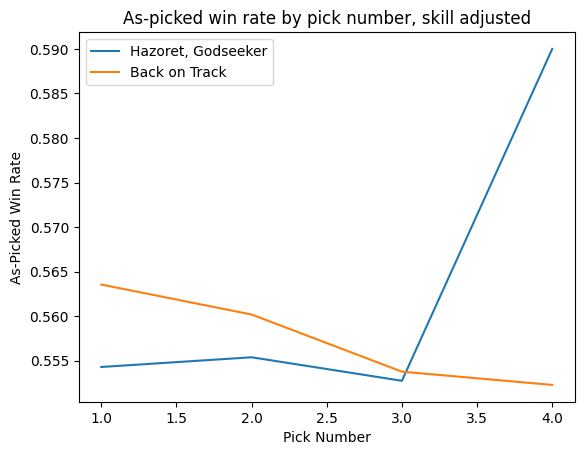

name,adj_wr
Back on Track,56.0%
"Hazoret, Godseeker",55.7%


In [6]:
by_pick_df = df.group_by('pick_num', 'name').sum().select('pick_num', 'name', wr_col)
_, ax = plt.subplots()
for name in names:
    curve = by_pick_df.filter(pl.col("name")==name)
    curve = curve.sort("pick_num") 
    ax.plot(
        curve["pick_num"],
        curve["adj_wr"],
        label=name     
    )
ax.legend()
ax.set_title("As-picked win rate by pick number, skill adjusted")
ax.set_xlabel("Pick Number")
ax.set_ylabel("As-Picked Win Rate")

plt.show()

agg_df = df.group_by('name').sum().select('name', wr_col)
GT(agg_df).fmt_percent('adj_wr', decimals=1)


Favor performs better in picks one through three, despite Abrade's dominance in the middle picks! Our earlier hypothesis about openness could explain that: Abrade's availability is a function of openness, so the presence of it in your pool might be a signal that red was more open than usual, which should reduce our confidence in the high win rates observed. Additionally, the overall performance of Favor in the as-picked metric is dampened by garbage-time pick ups for drafters in different colors.

Now, we could simply conclude that Favor is simply the better early pick, but there are reasons to be cautious as well. The dominant portion of the sample is in the later picks, and we don't know for sure what conditions explain the high win rate as an early pick. For example, it could be that drafters take Abrade more highly than Favor in splashing situations, or in control decks that were overall less effective in the format.

Where does that leave us? Perhaps a mild preference for Favor given everything we've observed. But then again, if you're actually choosing between Abrade and Favor, you might want to consider the signal you're sending. You could also use your knowledge of the game of Magic to choose, if that's what you're into.

Let's run this analysis back on a couple more examples to see if there's a consistent pattern.

## BLB: Scales of Shale vs Nocturnal Hunger

Since we are also interested in Engine Rat vs Spin Out, which shows the same effect, let's look at another black three mana removal spell, Nocturnal Hunger.

Here's our day 10 data table:

Name | ATA | GIH WR  | DEq | DEq Grade
---| --- | --- | --- | --- 
 Nocturnal Hunger | 4.47 | 57.4% | +2.05% |  B-
 Scales of Shale | 8.92 | 58.2% | +0.54% | C

First thing to note is that DEq is clearly too low. By the end if the format it was clear that Scales is a solid C+. At this point adoption was still low: just over 50% play rate, so it wasn't clear from the data how it would play out. Let's just run out the full analysis from before.

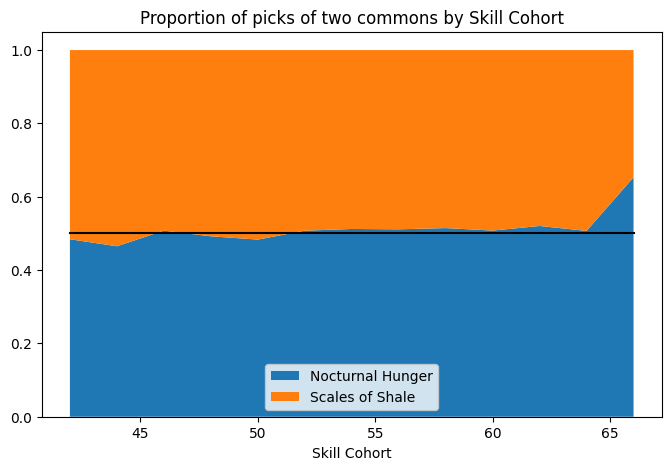

In [115]:
sample_names = ["Nocturnal Hunger", "Scales of Shale"]
sample_set = "BLB"
df = summon(
    sample_set, i
    columns=['picked_match_wr', 'event_matches_sum'], 
    group_by=['skill_cohort', 'pick_num', 'name'],
    extensions=ext
).filter(pl.col('name').is_in(sample_names))
ratio = (df.group_by('skill_cohort', 'name').sum()
         .select('skill_cohort', 'name', (pl.col('event_matches_sum') / pl.col('event_matches_sum').sum().over('skill_cohort')).alias('pick_ratio'))
         .sort('skill_cohort')
        )
_, ax = plt.subplots(figsize=(8,5))
skill_cohorts = ratio['skill_cohort'].unique().sort()
ax.stackplot(skill_cohorts, [ratio.filter(pl.col('name') == name)['pick_ratio'] for name in sample_names], labels=sample_names)
ax.plot(skill_cohorts, np.full(skill_cohorts.shape[0], 0.5), color="black")
ax.set_title('Proportion of picks of two commons by Skill Cohort')
ax.set_xlabel('Skill Cohort')
ax.legend()
plt.show()


In [119]:
skill_adj_df = (
    df.join(ratio, on=["skill_cohort", "name"])
    .with_columns((pl.col('event_matches_sum') / pl.col('pick_ratio')).alias('weight'))
    .with_columns((pl.col('picked_match_wr') * pl.col('weight')).alias('win_weight'))
    .select("event_matches_sum", 'pick_num', 'name', 'weight', 'win_weight')
    .group_by('pick_num', 'name').sum()
)

skill_adj_wr_df = skill_adj_df.group_by('name').sum().select('name', (pl.col('win_weight') / pl.col('weight')).alias('skill_adj_wr'))

from great_tables import GT
base_df = summon(sample_set, columns=["picked_match_wr"], extensions=ext).filter(pl.col('name').is_in(sample_names))
wr_df = base_df.join(skill_adj_wr_df, on='name')

adj_df =skill_adj_df.filter(
    pl.col("event_matches_sum")>1000
).with_columns(
    (pl.col("weight").sum().over("pick_num")).alias("pick_weight")
).filter(
    pl.col("pick_weight") > pl.col("weight")
).with_columns(
    (pl.col("weight") / pl.col("pick_weight")).alias("ratio")
).with_columns(
    (pl.col("win_weight") / pl.col("ratio")).alias("pick_win_weight")
).group_by("name").sum().with_columns(
    (pl.col("pick_win_weight") / pl.col("pick_weight")).alias("adj_wr")
)

GT(adj_df.select("name", "adj_wr").join(
    wr_df, on="name")).fmt_number(
    columns=["picked_match_wr", "skill_adj_wr","adj_wr"], scale_by=100, decimals=1)



name,adj_wr,picked_match_wr,skill_adj_wr
Nocturnal Hunger,55.7,55.2,55.1
Scales of Shale,55.6,55.5,55.6


name,adj_wr,picked_match_wr,skill_adj_wr
Scales of Shale,55.6,55.5,55.6
Nocturnal Hunger,55.7,55.2,55.1


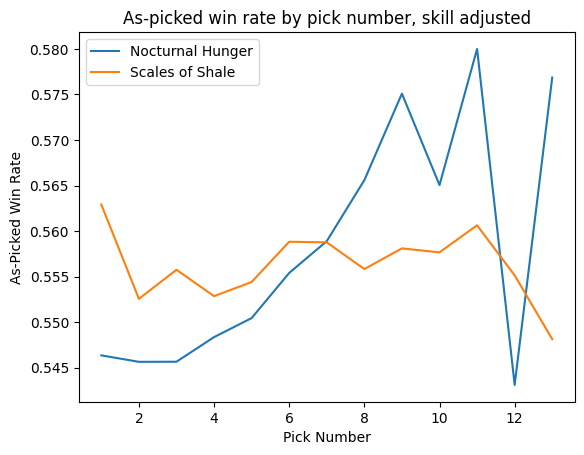

In [118]:
by_pick_df = skill_adj_df.filter(pl.col("event_matches_sum")>1000)
_, ax = plt.subplots()
for name in sample_names:
    curve = by_pick_df.filter(pl.col("name")==name)
    curve = curve.sort("pick_num") 
    ax.plot(
        curve["pick_num"],
        curve.select(pl.col("win_weight")/pl.col("weight")),
        label=name     
    )
ax.legend()
ax.set_title("As-picked win rate by pick number, skill adjusted")
ax.set_xlabel("Pick Number")
ax.set_ylabel("As-Picked Win Rate")

plt.show()

This is an even more extreme version of the phenomenon from before. Taking Scales of Shale early was clearly a viable strategy. Of course, with a little format knowledge, it's obvious that it isn't as simple as "Scales is better than Hunger." More than anything else, the data suggests the value of committing early to an underdrafted linear strategy. The lizard deck was powerful and relied mostly on underdrafted cards. An early committal evidently gave one a solid chance of ending up with an above average. 

That said I don't necessarily attribute that to the power of Scales in particular. If the card was boosting win rates that much by itself, we'd expect to see some bonus for picking them up late. Conversely, it is clearly important to be attuned to cards like Nocturnal Hunger going around past pick six -- a clear signal that black is open.

This example reminds me of the concept of "gumption" strategies developed by the Lords of Limited podcast. The idea is that certain strategies can be forced because they rely on a critical mass of late commons, and that you might sinply want to start taking those late commons early in the draft regardless of card quality in order to maximize the ultimate synergy of your linear deck.

OK, one more example.

## OTJ: Mystical Tether vs Take Up the Shield

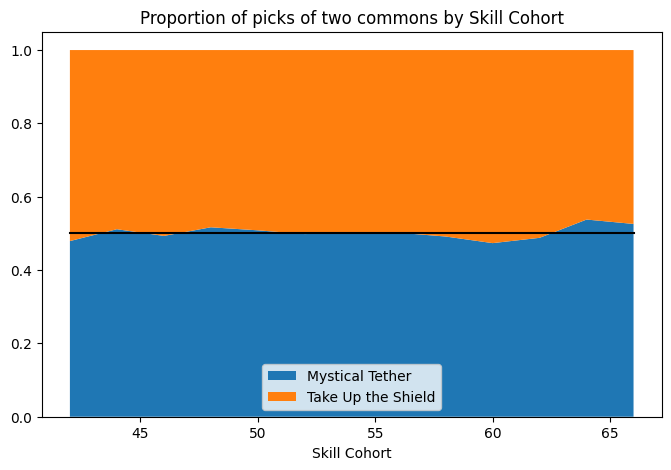

In [121]:
sample_names = ["Mystical Tether", "Take Up the Shield"]
sample_set = "OTJ"
df = summon(
    sample_set,
    columns=['picked_match_wr', 'event_matches_sum'], 
    group_by=['skill_cohort', 'pick_num', 'name'],
    extensions=ext
).filter(pl.col('name').is_in(sample_names))
ratio = (df.group_by('skill_cohort', 'name').sum()
         .select('skill_cohort', 'name', (pl.col('event_matches_sum') / pl.col('event_matches_sum').sum().over('skill_cohort')).alias('pick_ratio'))
         .sort('skill_cohort')
        )
_, ax = plt.subplots(figsize=(8,5))
skill_cohorts = ratio['skill_cohort'].unique().sort()
ax.stackplot(skill_cohorts, [ratio.filter(pl.col('name') == name)['pick_ratio'] for name in sample_names], labels=sample_names)
ax.plot(skill_cohorts, np.full(skill_cohorts.shape[0], 0.5), color="black")
ax.set_title('Proportion of picks of two commons by Skill Cohort')
ax.set_xlabel('Skill Cohort')
ax.legend()
plt.show()

In [122]:
skill_adj_df = (
    df.join(ratio, on=["skill_cohort", "name"])
    .with_columns((pl.col('event_matches_sum') / pl.col('pick_ratio')).alias('weight'))
    .with_columns((pl.col('picked_match_wr') * pl.col('weight')).alias('win_weight'))
    .select("event_matches_sum", 'pick_num', 'name', 'weight', 'win_weight')
    .group_by('pick_num', 'name').sum()
)

skill_adj_wr_df = skill_adj_df.group_by('name').sum().select('name', (pl.col('win_weight') / pl.col('weight')).alias('skill_adj_wr'))

from great_tables import GT
base_df = summon(sample_set, columns=["picked_match_wr"], extensions=ext).filter(pl.col('name').is_in(sample_names))
wr_df = base_df.join(skill_adj_wr_df, on='name')

adj_df =skill_adj_df.filter(
    pl.col("event_matches_sum")>1000
).with_columns(
    (pl.col("weight").sum().over("pick_num")).alias("pick_weight")
).filter(
    pl.col("pick_weight") > pl.col("weight")
).with_columns(
    (pl.col("weight") / pl.col("pick_weight")).alias("ratio")
).with_columns(
    (pl.col("win_weight") / pl.col("ratio")).alias("pick_win_weight")
).group_by("name").sum().with_columns(
    (pl.col("pick_win_weight") / pl.col("pick_weight")).alias("adj_wr")
)

GT(adj_df.select("name", "adj_wr").join(
    wr_df, on="name")).fmt_number(
    columns=["picked_match_wr", "skill_adj_wr","adj_wr"], scale_by=100, decimals=1)




name,adj_wr,picked_match_wr,skill_adj_wr
Mystical Tether,55.9,55.4,55.4
Take Up the Shield,55.7,55.9,55.8


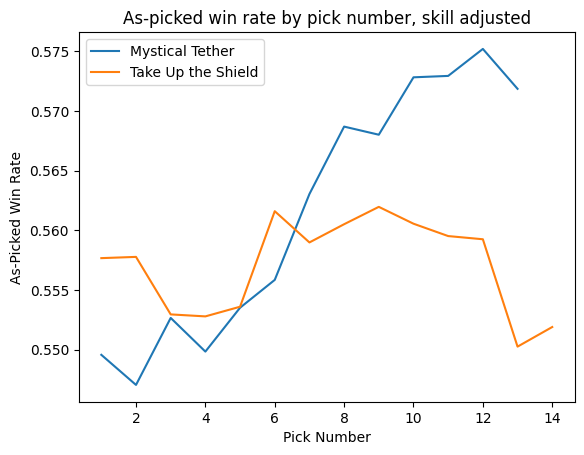

In [123]:
by_pick_df = skill_adj_df.filter(pl.col("event_matches_sum")>1000)
_, ax = plt.subplots()
for name in sample_names:
    curve = by_pick_df.filter(pl.col("name")==name)
    curve = curve.sort("pick_num") 
    ax.plot(
        curve["pick_num"],
        curve.select(pl.col("win_weight")/pl.col("weight")),
        label=name     
    )
ax.legend()
ax.set_title("As-picked win rate by pick number, skill adjusted")
ax.set_xlabel("Pick Number")
ax.set_ylabel("As-Picked Win Rate")

plt.show()